<a href="https://colab.research.google.com/github/Sirmj-1986/mj/blob/main/Anomalycode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [69]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [70]:
!pip install -q geopandas rasterio pyproj shapely fiona xarray matplotlib pandas numpy

In [71]:
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt

from rasterio.features import geometry_mask
from rasterio.transform import from_origin
from pyproj import Transformer
from mpl_toolkits.mplot3d import Axes3D

In [72]:
roi_path = "/content/drive/MyDrive/MJ/ROI.shp"
as_path  = "/content/drive/MyDrive/MJ/Anomaly_Aerocsv/CSV/Analytic_Signal.csv"
hgm_path = "/content/drive/MyDrive/MJ/Anomaly_Aerocsv/CSV/HGM.csv"

native_crs = "EPSG:4326"
target_crs = "EPSG:32632"

AS_UNIT = "nT/m"
HGM_UNIT = "nT/m"
AREA_UNIT = "km²"

as_low_percentile = 2
as_n_thresholds = 200
min_points = 15
n_boot = 200

hgm_percentile_1 = 90
hgm_percentile_2 = 95

threshold_counts = [100, 150, 200, 250, 300]

In [73]:
def read_grid_csv(csv_path, name, decimals=6):
    df = pd.read_csv(csv_path, usecols=["Lon", "Lat", "Z"]).copy()

    df["Lon"] = df["Lon"].round(decimals)
    df["Lat"] = df["Lat"].round(decimals)

    lon = np.sort(df["Lon"].unique())
    lat = np.sort(df["Lat"].unique())

    grid = (
        df.pivot(index="Lat", columns="Lon", values="Z")
          .reindex(index=lat, columns=lon)
          .sort_index(ascending=False)
    )

    da = xr.DataArray(
        grid.to_numpy(),
        dims=("Lat", "Lon"),
        coords={"Lat": grid.index.to_numpy(), "Lon": grid.columns.to_numpy()},
        name=name,
        attrs={"crs": native_crs}
    )
    return da


def mask_to_roi(da, roi_gdf):
    if str(roi_gdf.crs) != da.attrs["crs"]:
        roi_gdf = roi_gdf.to_crs(da.attrs["crs"])

    lon = da["Lon"].values
    lat = da["Lat"].values

    xres = float(abs(lon[1] - lon[0]))
    yres = float(abs(lat[1] - lat[0]))

    west = lon.min() - xres / 2
    north = lat.max() + yres / 2
    transform = from_origin(west, north, xres, yres)

    mask = geometry_mask(
        roi_gdf.geometry,
        transform=transform,
        invert=True,
        out_shape=(len(lat), len(lon))
    )

    mask_da = xr.DataArray(mask, dims=("Lat", "Lon"), coords={"Lat": lat, "Lon": lon})
    out = da.where(mask_da)
    out.attrs["crs"] = da.attrs["crs"]
    return out


def get_cell_geometry(da, source_crs=native_crs, target_crs=target_crs):
    lon = da["Lon"].values
    lat = da["Lat"].values

    transformer = Transformer.from_crs(source_crs, target_crs, always_xy=True)

    x0, y0 = transformer.transform(lon[0], lat[0])
    x1, y1 = transformer.transform(lon[1], lat[0])
    x2, y2 = transformer.transform(lon[0], lat[1])

    dx = abs(x1 - x0)
    dy = abs(y2 - y0)
    area_km2 = (dx * dy) / 1e6

    return dx, dy, area_km2


def get_positive_values(da):
    vals = da.values
    vals = vals[np.isfinite(vals)]
    vals = vals[vals > 0]
    return vals

In [74]:
roi = gpd.read_file(roi_path).to_crs(native_crs)

AS = mask_to_roi(read_grid_csv(as_path, "AS"), roi)
HGM = mask_to_roi(read_grid_csv(hgm_path, "HGM"), roi)

dx, dy, cell_area_km2 = get_cell_geometry(AS)

print("Loaded grids:")
print("AS shape:", AS.shape)
print("HGM shape:", HGM.shape)
print("ROI CRS:", roi.crs)
print("Grid CRS:", AS.attrs["crs"])

print("\nProjected grid geometry:")
print(f"dx = {dx:.3f} m")
print(f"dy = {dy:.3f} m")
print(f"cell_area = {cell_area_km2:.8f} {AREA_UNIT}")

Loaded grids:
AS shape: (1101, 1102)
HGM shape: (1101, 1102)
ROI CRS: EPSG:4326
Grid CRS: EPSG:4326

Projected grid geometry:
dx = 100.131 m
dy = 100.515 m
cell_area = 0.01006469 km²


In [75]:
def summarize_values(vals, label):
    return pd.DataFrame([{
        "Grid": label,
        "Count": len(vals),
        "Min": np.min(vals),
        "P1": np.percentile(vals, 1),
        "P2": np.percentile(vals, 2),
        "P5": np.percentile(vals, 5),
        "P10": np.percentile(vals, 10),
        "P25": np.percentile(vals, 25),
        "Median": np.percentile(vals, 50),
        "P75": np.percentile(vals, 75),
        "P90": np.percentile(vals, 90),
        "P95": np.percentile(vals, 95),
        "P99": np.percentile(vals, 99),
        "Max": np.max(vals),
        "Mean": np.mean(vals),
        "Std": np.std(vals)
    }])

as_vals = get_positive_values(AS)
hgm_vals = get_positive_values(HGM)

stats_df = pd.concat([
    summarize_values(as_vals, "AS"),
    summarize_values(hgm_vals, "HGM")
], ignore_index=True)

print(stats_df.T)

                0         1
Grid           AS       HGM
Count     1211098   1211098
Min      0.000438   0.00007
P1       0.005279   0.00244
P2       0.006725  0.003319
P5       0.009632  0.005107
P10       0.01328  0.007453
P25      0.023838  0.014452
Median    0.05098  0.031739
P75      0.111459  0.071602
P90      0.227402  0.148892
P95      0.351529   0.23558
P99       0.91232   0.58889
Max     11.125525  8.367542
Mean      0.10629  0.068671
Std      0.212947  0.140862


Analytic Signal display stretch:
vmin (P2)  = 0.006725 nT/m
vmax (P98) = 0.604962 nT/m


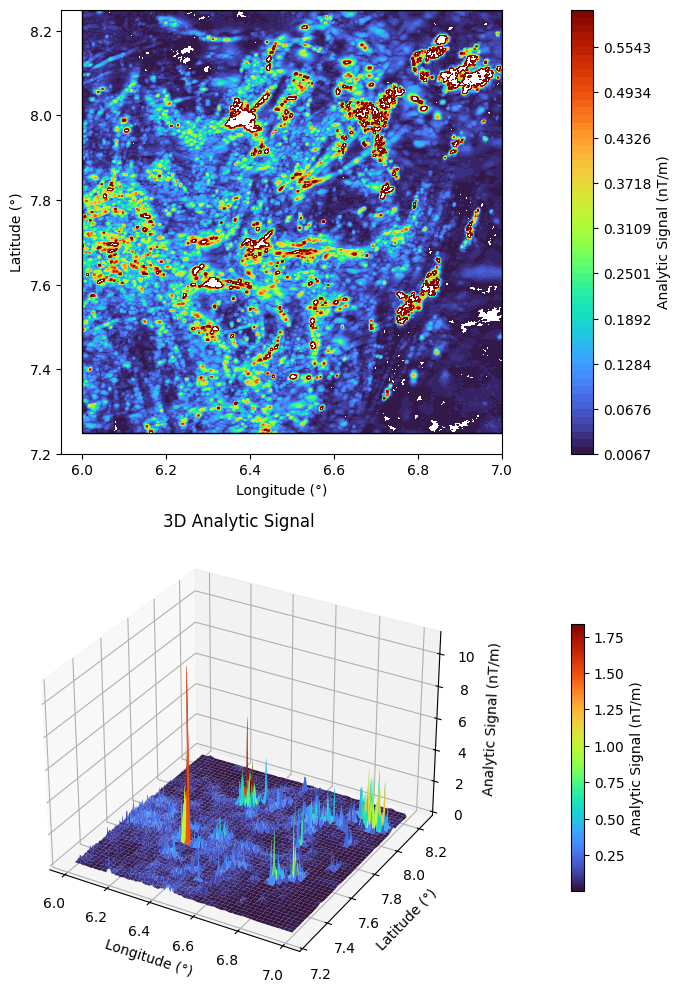

HGM display stretch:
vmin (P2)  = 0.003319 nT/m
vmax (P98) = 0.401222 nT/m


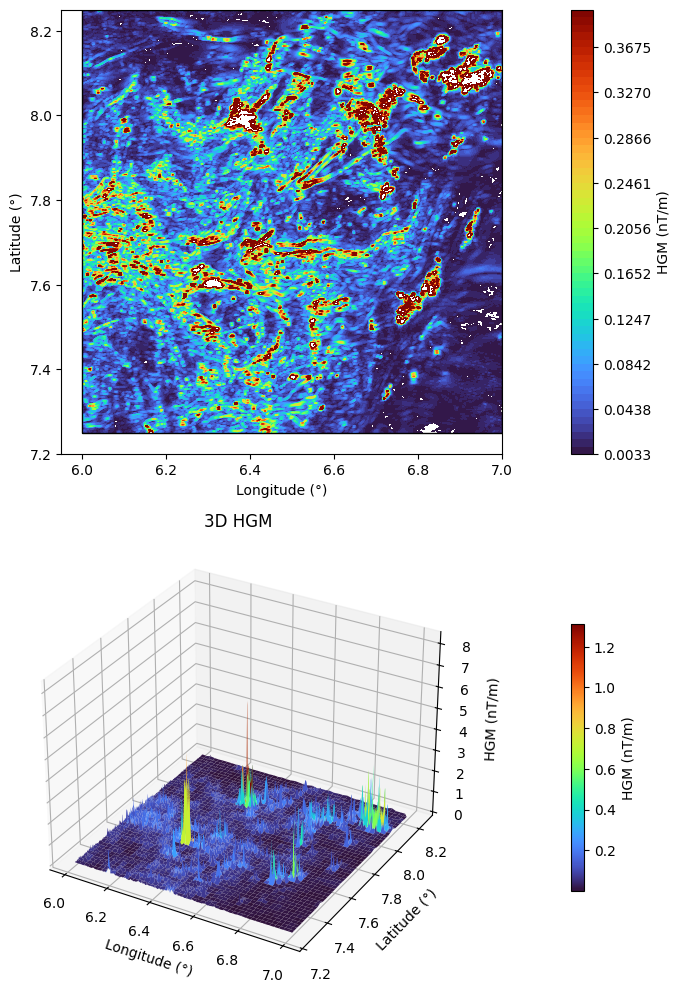

In [108]:
def plot_2d_3d(da, roi, title, unit):
    vals = get_positive_values(da)
    vmin = np.percentile(vals, 2)
    vmax = np.percentile(vals, 98)

    print(f"{title} display stretch:")
    print(f"vmin (P2)  = {vmin:.6f} {unit}")
    print(f"vmax (P98) = {vmax:.6f} {unit}")

    fig = plt.figure(figsize=(14, 10))

    ax1 = fig.add_subplot(2, 1, 1)
    cf = ax1.contourf(
        da["Lon"].values,
        da["Lat"].values,
        da.values,
        levels=np.linspace(vmin, vmax, 60),
        cmap="turbo"
    )
    roi.boundary.plot(ax=ax1, color="black", linewidth=1)
    plt.colorbar(cf, ax=ax1, label=f"{title} ({unit})")
    #ax1.set_title(f"2D {title}")
    ax1.set_xlabel("Longitude (°)")
    ax1.set_ylabel("Latitude (°)")

    ax2 = fig.add_subplot(2, 1, 2, projection="3d")
    X, Y = np.meshgrid(da["Lon"].values, da["Lat"].values)
    Z = np.where(np.isfinite(da.values), da.values, np.nan)

    surf = ax2.plot_surface(X, Y, Z, cmap="turbo", linewidth=0, antialiased=True)
    fig.colorbar(surf, ax=ax2, shrink=0.6, pad=0.08, label=f"{title} ({unit})")
    ax2.set_title(f"3D {title}")
    ax2.set_xlabel("Longitude (°)")
    ax2.set_ylabel("Latitude (°)")
    ax2.set_zlabel(f"{title} ({unit})")

    plt.tight_layout()
    plt.show()

plot_2d_3d(AS, roi, "Analytic Signal", AS_UNIT)
plot_2d_3d(HGM, roi, "HGM", HGM_UNIT)

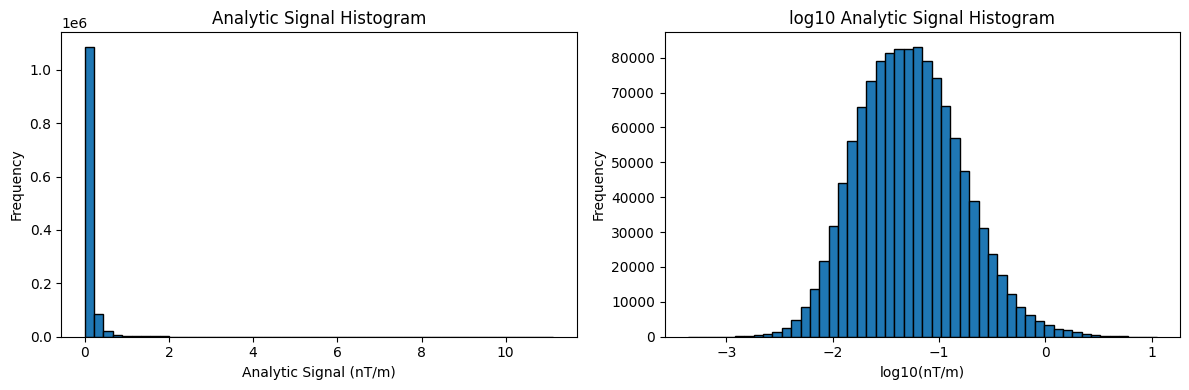

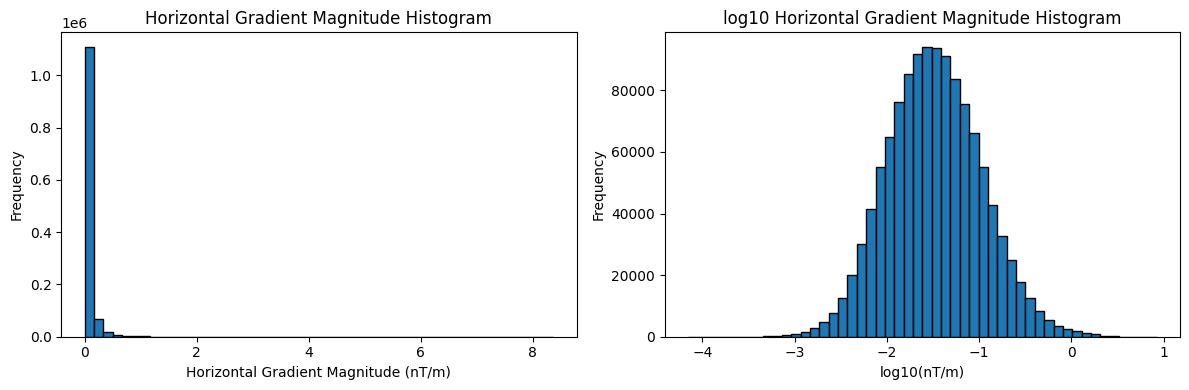

In [77]:
def plot_histograms(da, title, unit):
    vals = get_positive_values(da)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(vals, bins=50, edgecolor="black")
    axes[0].set_title(f"{title} Histogram")
    axes[0].set_xlabel(f"{title} ({unit})")
    axes[0].set_ylabel("Frequency")

    axes[1].hist(np.log10(vals), bins=50, edgecolor="black")
    axes[1].set_title(f"log10 {title} Histogram")
    axes[1].set_xlabel(f"log10({unit})")
    axes[1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

plot_histograms(AS, "Analytic Signal", AS_UNIT)
plot_histograms(HGM, "Horizontal Gradient Magnitude", HGM_UNIT)

In [78]:
def compute_ca_curve(da, cell_area_km2, n_thresholds, low_percentile, grid_unit):
    vals = get_positive_values(da)

    vmin = np.percentile(vals, low_percentile)
    vmax = np.max(vals)

    print(f"{da.name} C-A input values:")
    print(f"low_percentile = P{low_percentile}")
    print(f"vmin = {vmin:.6f} {grid_unit}")
    print(f"vmax = {vmax:.6f} {grid_unit}")
    print(f"n_thresholds = {n_thresholds}")

    thresholds = np.logspace(np.log10(vmin), np.log10(vmax), n_thresholds)

    arr = da.values
    valid = np.isfinite(arr)
    rows = []

    for t in thresholds:
        count = np.sum((arr >= t) & valid)
        area_km2 = count * cell_area_km2
        if area_km2 > 0:
            rows.append((t, count, area_km2, np.log10(t), np.log10(area_km2)))

    out = pd.DataFrame(rows, columns=[
        "threshold", "count", "area_km2", "log_threshold", "log_area"
    ])

    print(f"{da.name} usable C-A rows: {len(out)}")
    return out

ca_as = compute_ca_curve(
    AS,
    cell_area_km2=cell_area_km2,
    n_thresholds=as_n_thresholds,
    low_percentile=as_low_percentile,
    grid_unit=AS_UNIT
)

AS C-A input values:
low_percentile = P2
vmin = 0.006725 nT/m
vmax = 11.125525 nT/m
n_thresholds = 200
AS usable C-A rows: 199


In [79]:
def segment_fit_stats(x, y, breaks):
    starts = [0] + list(breaks)
    ends = list(breaks) + [len(x)]

    models = []
    sse = 0.0

    for a, b in zip(starts, ends):
        xs, ys = x[a:b], y[a:b]
        m, c = np.polyfit(xs, ys, 1)
        yhat = m * xs + c
        sse += np.sum((ys - yhat) ** 2)
        models.append((m, c))

    n = len(x)
    k = 2 * len(models) + len(breaks)
    aic = n * np.log(sse / n) + 2 * k
    bic = n * np.log(sse / n) + k * np.log(n)

    return {"breaks": breaks, "models": models, "sse": sse, "aic": aic, "bic": bic}


def fit_piecewise_fast(ca_df, n_segments, min_points):
    x = ca_df["log_threshold"].values
    y = ca_df["log_area"].values
    n = len(x)

    best = None
    best_bic = np.inf

    if n_segments == 2:
        for i in range(min_points, n - min_points):
            res = segment_fit_stats(x, y, [i])
            if res["bic"] < best_bic:
                best_bic = res["bic"]
                best = res

    elif n_segments == 3:
        for i in range(min_points, n - 2 * min_points):
            for j in range(i + min_points, n - min_points):
                res = segment_fit_stats(x, y, [i, j])
                if res["bic"] < best_bic:
                    best_bic = res["bic"]
                    best = res
    else:
        raise ValueError("Use only 2 or 3 segments for fast execution.")

    return best


def select_best_model_fast(ca_df, min_points):
    rows = []
    models = {}

    for nseg in [2, 3]:
        model = fit_piecewise_fast(ca_df, n_segments=nseg, min_points=min_points)
        models[nseg] = model
        rows.append({
            "segments": nseg,
            "SSE": model["sse"],
            "AIC": model["aic"],
            "BIC": model["bic"]
        })

    table = pd.DataFrame(rows).sort_values("BIC").reset_index(drop=True)
    best_nseg = int(table.loc[0, "segments"])

    print("Fast model selection table:")
    print(table)

    print("Selected model by minimum BIC:")
    print(f"segments = {best_nseg}")
    print(f"AIC = {table.loc[0, 'AIC']:.6f}")
    print(f"BIC = {table.loc[0, 'BIC']:.6f}")

    return models[best_nseg], table, models


best_as, model_select_as, all_models_as = select_best_model_fast(
    ca_as,
    min_points=min_points
)

Fast model selection table:
   segments       SSE          AIC         BIC
0         3  1.102826 -1017.890405 -991.543966
1         2  5.202886  -715.174197 -698.707673
Selected model by minimum BIC:
segments = 3
AIC = -1017.890405
BIC = -991.543966


In [80]:
def extract_thresholds(ca_df, model):
    x = ca_df["log_threshold"].values
    return [10 ** x[i] for i in model["breaks"]]

as_thresholds = extract_thresholds(ca_as, best_as)

print("Extracted AS thresholds:")
for idx, t in enumerate(as_thresholds, start=1):
    print(f"T{idx} = {t:.6f} {AS_UNIT}")

if len(as_thresholds) < 2:
    raise ValueError("Selected model returned fewer than 2 thresholds.")

T1 = as_thresholds[0]
T2 = as_thresholds[1]

print("Thresholds used for AS classification:")
print(f"T1 = {T1:.6f} {AS_UNIT}")
print(f"T2 = {T2:.6f} {AS_UNIT}")

Extracted AS thresholds:
T1 = 0.101954 nT/m
T2 = 2.082062 nT/m
Thresholds used for AS classification:
T1 = 0.101954 nT/m
T2 = 2.082062 nT/m


In [81]:
print(type(ca_as))
print("best_as exists:", "best_as" in globals())

<class 'pandas.core.frame.DataFrame'>
best_as exists: True


In [82]:
def bootstrap_thresholds_fixed_breaks(ca_df, break_idx, n_boot=200, grid_unit="nT/m", seed=42):
    rng = np.random.default_rng(seed)

    x = ca_df["log_threshold"].values
    n = len(x)

    t1_list = []
    t2_list = []

    for _ in range(n_boot):
        xb = x[rng.integers(0, n, n)]
        xb.sort()

        if len(break_idx) >= 2:
            t1_list.append(10 ** xb[break_idx[0]])
            t2_list.append(10 ** xb[break_idx[1]])

    ci = pd.DataFrame({
        "Threshold": ["T1", "T2"],
        "Mean": [np.mean(t1_list), np.mean(t2_list)],
        "Std": [np.std(t1_list, ddof=1), np.std(t2_list, ddof=1)],
        "P2.5": [np.percentile(t1_list, 2.5), np.percentile(t2_list, 2.5)],
        "P50": [np.percentile(t1_list, 50), np.percentile(t2_list, 50)],
        "P97.5": [np.percentile(t1_list, 97.5), np.percentile(t2_list, 97.5)],
        "N_boot": [len(t1_list), len(t2_list)],
        "Unit": [grid_unit, grid_unit]
    })

    print("Fast bootstrap CI table:")
    print(ci)

    return ci, t1_list, t2_list


break_idx = best_as["breaks"]
print("Original breakpoint indices:", break_idx)
print("Selected segment count:", len(best_as["models"]))

bootstrap_ci_as, t1_boot, t2_boot = bootstrap_thresholds_fixed_breaks(
    ca_as,
    break_idx=break_idx,
    n_boot=n_boot,
    grid_unit=AS_UNIT,
    seed=42
)

Original breakpoint indices: [73, 154]
Selected segment count: 3
Fast bootstrap CI table:
  Threshold      Mean       Std      P2.5       P50     P97.5  N_boot  Unit
0        T1  0.104570  0.028072  0.060530  0.098227  0.165450     200  nT/m
1        T2  2.068106  0.454623  1.380967  2.005948  3.136222     200  nT/m


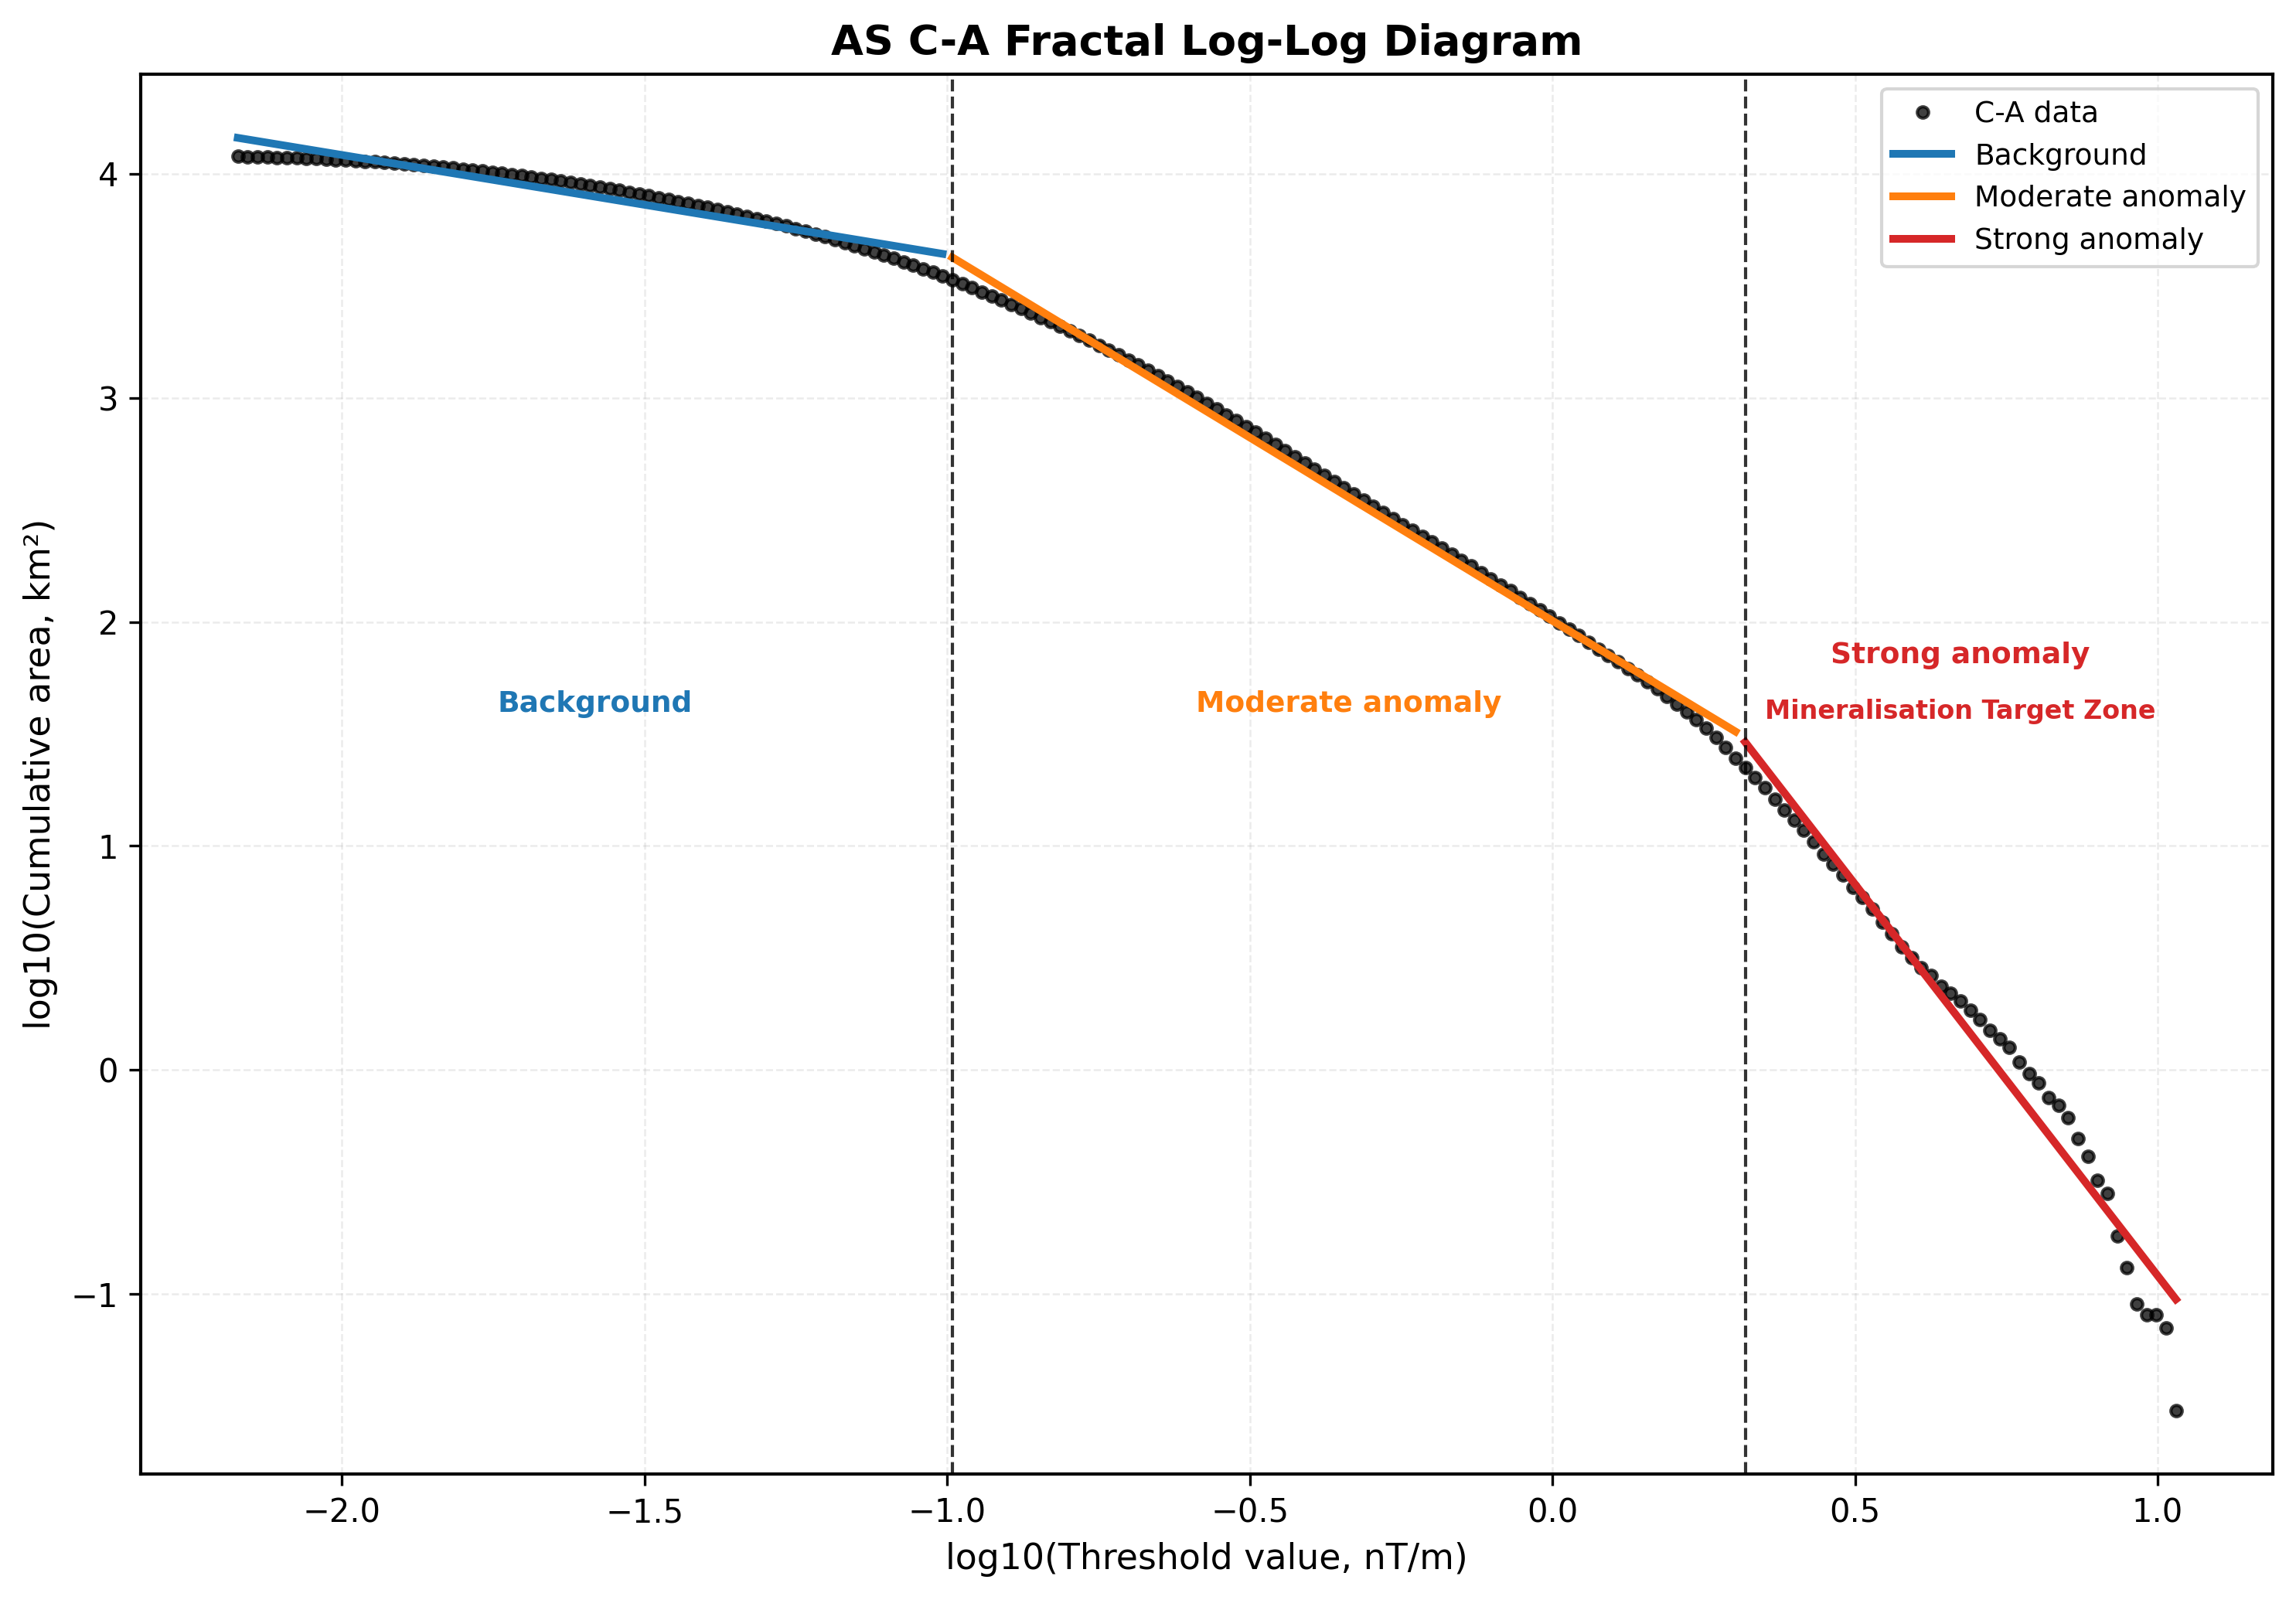

In [83]:
def plot_ca_labeled(ca_df, model, title, grid_unit):
    x = ca_df["log_threshold"].values
    y = ca_df["log_area"].values
    breaks = model["breaks"]
    models = model["models"]

    labels = ["Background", "Moderate anomaly", "Strong anomaly"]
    sub_labels = ["", "", "Mineralisation Target Zone"]
    line_colors = ["#1f77b4", "#ff7f0e", "#d62728"]  # blue, orange, red

    fig, ax = plt.subplots(figsize=(10, 7), dpi=300)

    ax.plot(
        x, y,
        linestyle="None",
        marker="o",
        markersize=3.5,
        markerfacecolor="black",
        markeredgecolor="black",
        alpha=0.75,
        label="C-A data"
    )

    starts = [0] + list(breaks)
    ends = list(breaks) + [len(x)]

    for idx, (a, b, (m, c)) in enumerate(zip(starts, ends, models)):
        ax.plot(
            x[a:b],
            m * x[a:b] + c,
            lw=2.4,
            color=line_colors[idx],
            label=labels[idx]
        )

    for bi in breaks[:2]:
        ax.axvline(
            x[bi],
            color="black",
            ls="--",
            lw=1.0,
            alpha=0.8
        )

    y_min, y_max = ax.get_ylim()
    y_mid = y_min + 0.55 * (y_max - y_min)

    zone_bounds = [x[0]] + [x[i] for i in breaks[:2]] + [x[-1]]

    for i, label in enumerate(labels):
        x_mid = (zone_bounds[i] + zone_bounds[i + 1]) / 2

        if i == 2:
            ax.text(
                x_mid,
                y_mid + 0.035 * (y_max - y_min),
                label,
                fontsize=9,
                fontweight="bold",
                color=line_colors[i],
                ha="center",
                va="center"
            )
            ax.text(
                x_mid,
                y_mid - 0.005 * (y_max - y_min),
                sub_labels[i],
                fontsize=8,
                fontweight="bold",
                color=line_colors[i],
                ha="center",
                va="center"
            )
        else:
            ax.text(
                x_mid,
                y_mid,
                label,
                fontsize=9,
                fontweight="bold",
                color=line_colors[i],
                ha="center",
                va="center"
            )

    ax.set_xlabel(f"log10(Threshold value, {grid_unit})", fontsize=11)
    ax.set_ylabel(f"log10(Cumulative area, {AREA_UNIT})", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold")

    ax.grid(True, alpha=0.25, linestyle="--", linewidth=0.6)
    ax.tick_params(axis="both", labelsize=10)

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

    ax.legend(frameon=True, fontsize=9, loc="best")
    plt.tight_layout()
    plt.show()


plot_ca_labeled(ca_as, best_as, "AS C-A Fractal Log-Log Diagram", AS_UNIT)

In [84]:
def classify_three_classes(da, t1, t2):
    arr = da.values
    out = np.full(arr.shape, np.nan, dtype=float)
    valid = np.isfinite(arr)

    out[valid & (arr < t1)] = 1
    out[valid & (arr >= t1) & (arr < t2)] = 2
    out[valid & (arr >= t2)] = 3

    out_da = xr.DataArray(out, dims=da.dims, coords=da.coords, name="AS_CA_Class")
    out_da.attrs["crs"] = da.attrs["crs"]
    return out_da


AS_class = classify_three_classes(AS, T1, T2)

print("Classification rule:")
print(f"Class 1 (Background):       AS < {T1:.6f} {AS_UNIT}")
print(f"Class 2 (Moderate anomaly): {T1:.6f} <= AS < {T2:.6f} {AS_UNIT}")
print(f"Class 3 (Strong anomaly):   AS >= {T2:.6f} {AS_UNIT}")

Classification rule:
Class 1 (Background):       AS < 0.101954 nT/m
Class 2 (Moderate anomaly): 0.101954 <= AS < 2.082062 nT/m
Class 3 (Strong anomaly):   AS >= 2.082062 nT/m


In [85]:
def class_area_table(class_da, cell_area_km2):
    vals = class_da.values

    n1 = np.sum(vals == 1)
    n2 = np.sum(vals == 2)
    n3 = np.sum(vals == 3)

    a1 = n1 * cell_area_km2
    a2 = n2 * cell_area_km2
    a3 = n3 * cell_area_km2
    total = a1 + a2 + a3

    return pd.DataFrame({
        "Class": ["Background", "Moderate anomaly", "Strong anomaly"],
        "Code": [1, 2, 3],
        "Cells": [n1, n2, n3],
        f"Area_{AREA_UNIT}": [a1, a2, a3],
        "Area_percent": [100 * a1 / total, 100 * a2 / total, 100 * a3 / total]
    })


as_class_table = class_area_table(AS_class, cell_area_km2)
print(as_class_table)

              Class  Code   Cells     Area_km²  Area_percent
0        Background     1  877614  8832.909398     72.464326
1  Moderate anomaly     2  331253  3333.957454     27.351461
2    Strong anomaly     3    2231    22.454315      0.184213


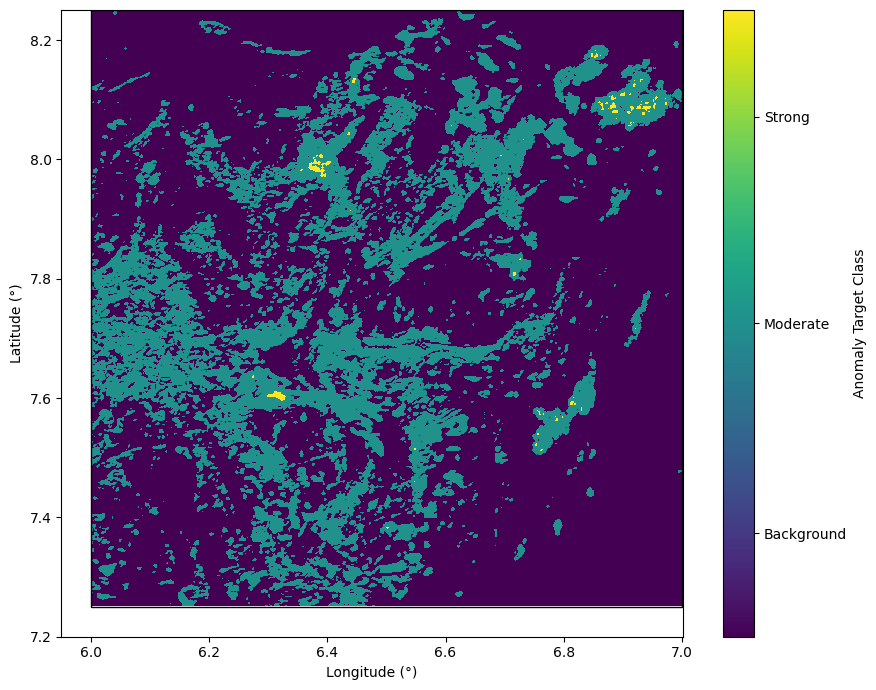

In [109]:
fig, ax = plt.subplots(figsize=(9, 7))

im = ax.pcolormesh(
    AS_class["Lon"].values,
    AS_class["Lat"].values,
    AS_class.values,
    cmap="viridis",
    shading="auto"
)
roi.boundary.plot(ax=ax, color="black", linewidth=1)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Anomaly Target Class")
cbar.set_ticks([1.33, 2.0, 2.66])
cbar.set_ticklabels(["Background", "Moderate", "Strong"])

#ax.set_title("Classified Analytic Signal Grid")
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")

plt.tight_layout()
plt.show()

In [87]:
def hgm_target_mask(hgm_da, percentile_cutoff):
    vals = get_positive_values(hgm_da)
    threshold = np.percentile(vals, percentile_cutoff)

    print("HGM targeting cutoff:")
    print(f"percentile = P{percentile_cutoff}")
    print(f"threshold  = {threshold:.6f} {HGM_UNIT}")

    mask = xr.DataArray(
        np.where(np.isfinite(hgm_da.values) & (hgm_da.values >= threshold), 1, 0),
        dims=hgm_da.dims,
        coords=hgm_da.coords,
        name=f"HGM_P{percentile_cutoff}"
    )
    mask.attrs["threshold"] = threshold
    return mask, threshold


HGM_top90, hgm_thr90 = hgm_target_mask(HGM, percentile_cutoff=hgm_percentile_1)
HGM_top95, hgm_thr95 = hgm_target_mask(HGM, percentile_cutoff=hgm_percentile_2)

HGM targeting cutoff:
percentile = P90
threshold  = 0.148892 nT/m
HGM targeting cutoff:
percentile = P95
threshold  = 0.235580 nT/m


In [88]:
def binary_mask_from_class(class_da, target_class=3):
    return xr.DataArray(
        np.where(class_da.values == target_class, 1, 0),
        dims=class_da.dims,
        coords=class_da.coords,
        name="binary_mask"
    )


def overlap_table(mask1, mask2, cell_area_km2, name1, name2):
    a = mask1.values == 1
    b = mask2.values == 1

    area1 = np.sum(a) * cell_area_km2
    area2 = np.sum(b) * cell_area_km2
    inter = np.sum(a & b) * cell_area_km2
    union = np.sum(a | b) * cell_area_km2

    jaccard = inter / union if union > 0 else np.nan
    overlap1 = inter / area1 if area1 > 0 else np.nan
    overlap2 = inter / area2 if area2 > 0 else np.nan

    return pd.DataFrame([{
        "Comparison": f"{name1} vs {name2}",
        f"Area_1_{AREA_UNIT}": area1,
        f"Area_2_{AREA_UNIT}": area2,
        f"Intersection_{AREA_UNIT}": inter,
        f"Union_{AREA_UNIT}": union,
        "Jaccard": jaccard,
        f"Intersection/{name1}": overlap1,
        f"Intersection/{name2}": overlap2
    }])


AS_strong = binary_mask_from_class(AS_class, target_class=3)

cmp90 = overlap_table(AS_strong, HGM_top90, cell_area_km2, "AS_strong", "HGM_top90")
cmp95 = overlap_table(AS_strong, HGM_top95, cell_area_km2, "AS_strong", "HGM_top95")

comparison_df = pd.concat([cmp90, cmp95], ignore_index=True)
print(comparison_df)

               Comparison  Area_1_km²   Area_2_km²  Intersection_km²  \
0  AS_strong vs HGM_top90   22.454315  1218.934130         22.454315   
1  AS_strong vs HGM_top95   22.454315   609.467065         22.454315   

     Union_km²   Jaccard  Intersection/AS_strong  Intersection/HGM_top90  \
0  1218.934130  0.018421                     1.0                0.018421   
1   609.467065  0.036843                     1.0                     NaN   

   Intersection/HGM_top95  
0                     NaN  
1                0.036843  


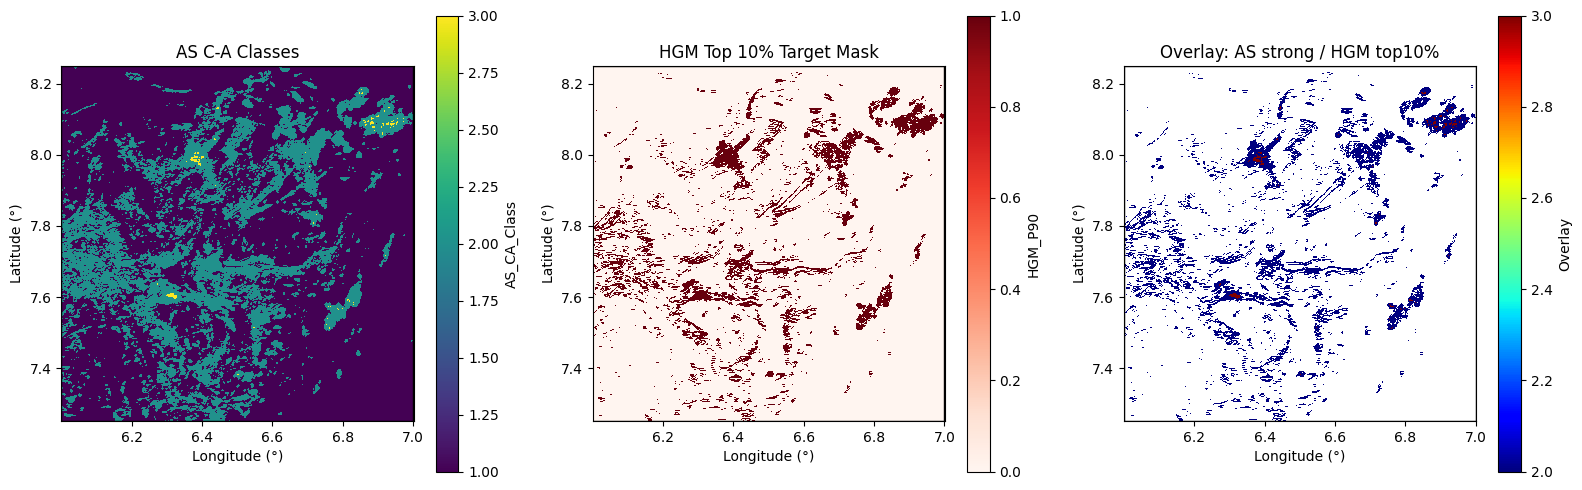

In [107]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

AS_class.plot(ax=axes[0], cmap="viridis", add_colorbar=True)
roi.boundary.plot(ax=axes[0], color="black", linewidth=1)
axes[0].set_title("AS C-A Classes")
axes[0].set_xlabel("Longitude (°)")
axes[0].set_ylabel("Latitude (°)")

HGM_top90.plot(ax=axes[1], cmap="Reds", add_colorbar=True)
roi.boundary.plot(ax=axes[1], color="black", linewidth=1)
axes[1].set_title("HGM Top 10% Target Mask")
axes[1].set_xlabel("Longitude (°)")
axes[1].set_ylabel("Latitude (°)")

overlay = np.where((AS_strong.values == 1) & (HGM_top90.values == 1), 3,
          np.where(AS_strong.values == 1, 1,
          np.where(HGM_top90.values == 1, 2, np.nan)))

overlay_da = xr.DataArray(overlay, dims=AS.dims, coords=AS.coords, name="Overlay")
overlay_da.plot(ax=axes[2], cmap="jet", add_colorbar=True)
roi.boundary.plot(ax=axes[2], color="black", linewidth=1)
axes[2].set_title("Overlay: AS strong / HGM top10%")
axes[2].set_xlabel("Longitude (°)")
axes[2].set_ylabel("Latitude (°)")

plt.tight_layout()
plt.show()

In [89]:
def sensitivity_test_fast(da, cell_area_km2, threshold_counts, low_percentile, min_points):
    rows = []

    for n in threshold_counts:
        ca = compute_ca_curve(
            da,
            cell_area_km2=cell_area_km2,
            n_thresholds=n,
            low_percentile=low_percentile,
            grid_unit=AS_UNIT
        )
        best, _, _ = select_best_model_fast(ca, min_points=min_points)
        th = extract_thresholds(ca, best)

        rows.append({
            "n_thresholds": n,
            "best_segments": len(best["models"]),
            "AIC": best["aic"],
            "BIC": best["bic"],
            "T1": th[0] if len(th) > 0 else np.nan,
            "T2": th[1] if len(th) > 1 else np.nan,
            "Threshold_unit": AS_UNIT
        })

    out = pd.DataFrame(rows)
    print(out)
    return out


sensitivity_df = sensitivity_test_fast(
    AS,
    cell_area_km2=cell_area_km2,
    threshold_counts=threshold_counts,
    low_percentile=as_low_percentile,
    min_points=min_points
)

AS C-A input values:
low_percentile = P2
vmin = 0.006725 nT/m
vmax = 11.125525 nT/m
n_thresholds = 100
AS usable C-A rows: 99
Fast model selection table:
   segments       SSE         AIC         BIC
0         3  0.429198 -522.654800 -501.893841
1         2  2.355081 -360.115928 -347.140329
Selected model by minimum BIC:
segments = 3
AIC = -522.654800
BIC = -501.893841
AS C-A input values:
low_percentile = P2
vmin = 0.006725 nT/m
vmax = 11.125525 nT/m
n_thresholds = 150
AS usable C-A rows: 149
Fast model selection table:
   segments       SSE         AIC         BIC
0         3  0.770994 -768.339185 -744.307614
1         2  3.802609 -536.570594 -521.550863
Selected model by minimum BIC:
segments = 3
AIC = -768.339185
BIC = -744.307614
AS C-A input values:
low_percentile = P2
vmin = 0.006725 nT/m
vmax = 11.125525 nT/m
n_thresholds = 200
AS usable C-A rows: 199
Fast model selection table:
   segments       SSE          AIC         BIC
0         3  1.102826 -1017.890405 -991.543966
1     

In [90]:
stats_df.to_csv("/content/drive/MyDrive/MJ/Anomaly_Aerocsv/CSV/AS_HGM_stats.csv", index=False)
ca_as.to_csv("/content/drive/MyDrive/MJ/Anomaly_Aerocsv/CSV/AS_CA_curve.csv", index=False)
model_select_as.to_csv("/content/drive/MyDrive/MJ/Anomaly_Aerocsv/CSV/AS_model_selection_AIC_BIC.csv", index=False)
bootstrap_ci_as.to_csv("/content/drive/MyDrive/MJ/Anomaly_Aerocsv/CSV/AS_bootstrap_CI_fast.csv", index=False)
as_class_table.to_csv("/content/drive/MyDrive/MJ/Anomaly_Aerocsv/CSV/AS_class_area_table.csv", index=False)
comparison_df.to_csv("/content/drive/MyDrive/MJ/Anomaly_Aerocsv/CSV/AS_HGM_comparison.csv", index=False)
sensitivity_df.to_csv("/content/drive/MyDrive/MJ/Anomaly_Aerocsv/CSV/AS_sensitivity_fast.csv", index=False)

AS_class.to_dataframe(name="AS_CA_Class").reset_index().to_csv(
    "/content/drive/MyDrive/MJ/Anomaly_Aerocsv/CSV/AS_CA_class_grid.csv",
    index=False
)

HGM_top90.to_dataframe(name="HGM_top90").reset_index().to_csv(
    "/content/drive/MyDrive/MJ/Anomaly_Aerocsv/CSV/HGM_top90_grid.csv",
    index=False
)

HGM_top95.to_dataframe(name="HGM_top95").reset_index().to_csv(
    "/content/drive/MyDrive/MJ/Anomaly_Aerocsv/CSV/HGM_top95_grid.csv",
    index=False
)

print("All outputs saved.")

All outputs saved.


In [91]:
sites_df = pd.DataFrame({
    "Site": ["Obajana", "Lokoja", "Ajaokuta", "Itakpe", "Okene", "Ibilo", "Okpella", "Koton Karfi"],
    "Lon":  [6.4258, 6.6868, 6.6016, 6.3105, 6.2144, 6.0743, 6.3627, 6.6923],
    "Lat":  [7.9501, 7.8195, 7.5827, 7.6154, 7.5391, 7.4139, 7.2913, 8.0861]
})

sites_gdf = gpd.GeoDataFrame(
    sites_df.copy(),
    geometry=gpd.points_from_xy(sites_df["Lon"], sites_df["Lat"]),
    crs=native_crs
)

print(sites_gdf)

          Site     Lon     Lat               geometry
0      Obajana  6.4258  7.9501  POINT (6.4258 7.9501)
1       Lokoja  6.6868  7.8195  POINT (6.6868 7.8195)
2     Ajaokuta  6.6016  7.5827  POINT (6.6016 7.5827)
3       Itakpe  6.3105  7.6154  POINT (6.3105 7.6154)
4        Okene  6.2144  7.5391  POINT (6.2144 7.5391)
5        Ibilo  6.0743  7.4139  POINT (6.0743 7.4139)
6      Okpella  6.3627  7.2913  POINT (6.3627 7.2913)
7  Koton Karfi  6.6923  8.0861  POINT (6.6923 8.0861)


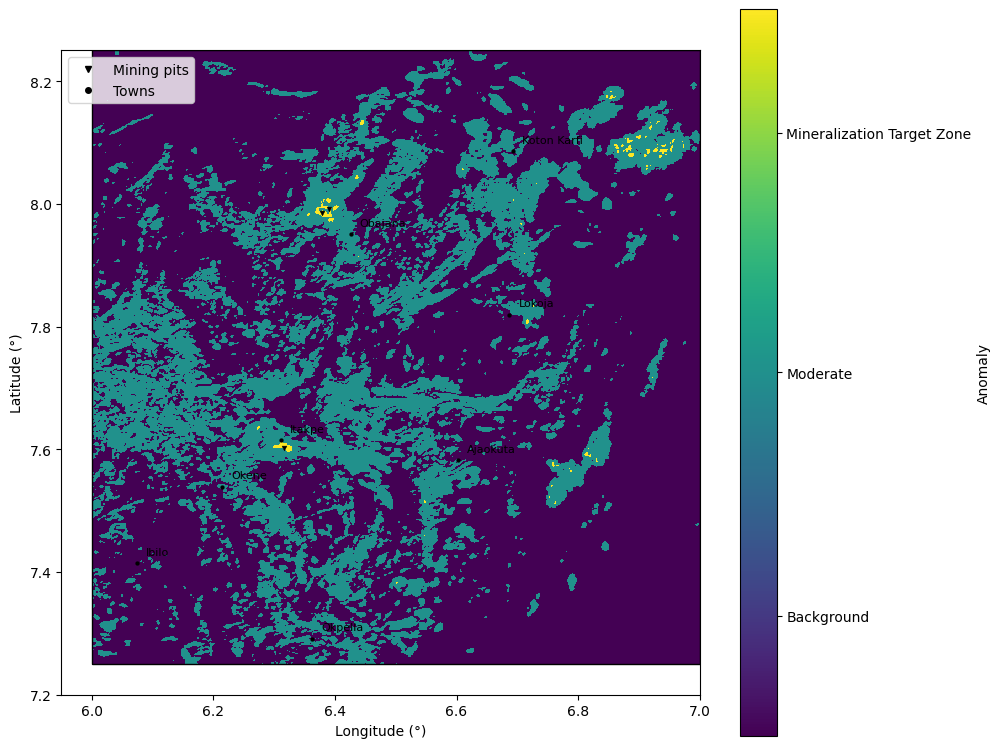

In [92]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.pcolormesh(
    AS_class["Lon"].values,
    AS_class["Lat"].values,
    AS_class.values,
    cmap="viridis",
    shading="auto"
)

roi.boundary.plot(ax=ax, color="black", linewidth=1)

# Mining pits: very small black triangle
pits_gdf.plot(
    ax=ax,
    color="black",
    marker="v",
    markersize=12,
    edgecolor="black",
    linewidth=0.3,
    zorder=6
)

# Towns: very small black circle
sites_gdf.plot(
    ax=ax,
    color="black",
    marker="o",
    markersize=8,
    edgecolor="black",
    linewidth=0.2,
    zorder=5
)

# Visible town labels without background
for _, row in sites_gdf.iterrows():
    ax.text(
        row.geometry.x + 0.015,
        row.geometry.y + 0.010,
        row["Site"],
        fontsize=8,
        color="black",
        ha="left",
        va="bottom",
        zorder=7
    )

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Anomaly")
cbar.set_ticks([1.33, 2.0, 2.66])
cbar.set_ticklabels(["Background", "Moderate", "Mineralization Target Zone"])

pit_handle = Line2D(
    [0], [0],
    marker="v",
    color="black",
    markerfacecolor="black",
    markeredgecolor="black",
    linestyle="None",
    markersize=5,
    label="Mining pits"
)

town_handle = Line2D(
    [0], [0],
    marker="o",
    color="black",
    markerfacecolor="black",
    markeredgecolor="black",
    linestyle="None",
    markersize=4,
    label="Towns"
)

roi_handle = Line2D(
    [0], [0],
    color="black",
    linewidth=1,
    label="ROI boundary"
)

ax.legend(handles=[pit_handle, town_handle], loc="upper left", frameon=True)

ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")

plt.tight_layout()
plt.show()

In [93]:
def extract_grid_value_at_points(da, points_gdf, value_name, id_prefix="Pt"):
    rows = []
    for i, row in points_gdf.reset_index(drop=True).iterrows():
        lon = row.geometry.x
        lat = row.geometry.y

        lon_idx = np.argmin(np.abs(da["Lon"].values - lon))
        lat_idx = np.argmin(np.abs(da["Lat"].values - lat))

        value = da.values[lat_idx, lon_idx]

        rows.append({
            "ID": f"{id_prefix}_{i+1}",
            "Lon": lon,
            "Lat": lat,
            value_name: value
        })
    return pd.DataFrame(rows)

In [94]:
pit_as_class = extract_grid_value_at_points(AS_class, pits_gdf, "AS_Class", id_prefix="Pit")
pit_as_value = extract_grid_value_at_points(AS, pits_gdf, "AS_Value", id_prefix="Pit")
pit_hgm_value = extract_grid_value_at_points(HGM, pits_gdf, "HGM_Value", id_prefix="Pit")
pit_hgm90 = extract_grid_value_at_points(HGM_top90, pits_gdf, "HGM_Top90", id_prefix="Pit")
pit_hgm95 = extract_grid_value_at_points(HGM_top95, pits_gdf, "HGM_Top95", id_prefix="Pit")

validation_df = pit_as_class.merge(pit_as_value, on=["ID", "Lon", "Lat"])
validation_df = validation_df.merge(pit_hgm_value, on=["ID", "Lon", "Lat"])
validation_df = validation_df.merge(pit_hgm90, on=["ID", "Lon", "Lat"])
validation_df = validation_df.merge(pit_hgm95, on=["ID", "Lon", "Lat"])

In [95]:
def as_class_label(x):
    if pd.isna(x):
        return "NoData"
    x = int(x)
    if x == 1:
        return "Background"
    elif x == 2:
        return "Moderate anomaly"
    elif x == 3:
        return "Strong anomaly"
    return "Unknown"

validation_df["AS_Class_Label"] = validation_df["AS_Class"].apply(as_class_label)
validation_df["In_HGM_Top90"] = validation_df["HGM_Top90"].astype(int)
validation_df["In_HGM_Top95"] = validation_df["HGM_Top95"].astype(int)

print("Pit-by-pit validation:")
print(validation_df[[
    "ID", "Lon", "Lat",
    "AS_Value", "AS_Class", "AS_Class_Label",
    "HGM_Value", "In_HGM_Top90", "In_HGM_Top95"
]])

Pit-by-pit validation:
      ID     Lon     Lat  AS_Value  AS_Class  AS_Class_Label  HGM_Value  \
0  Pit_1  6.3792  7.9859  7.697659       3.0  Strong anomaly   4.372677   
1  Pit_2  6.3901  7.9913  2.242306       3.0  Strong anomaly   0.904563   
2  Pit_3  6.3160  7.6022  2.706184       3.0  Strong anomaly   2.639014   

   In_HGM_Top90  In_HGM_Top95  
0             1             1  
1             1             1  
2             1             1  


In [96]:
n_pits = len(validation_df)
n_bg = np.sum(validation_df["AS_Class"] == 1)
n_mod = np.sum(validation_df["AS_Class"] == 2)
n_str = np.sum(validation_df["AS_Class"] == 3)
n_hgm90 = np.sum(validation_df["In_HGM_Top90"] == 1)
n_hgm95 = np.sum(validation_df["In_HGM_Top95"] == 1)

summary_validation = pd.DataFrame({
    "Metric": [
        "Total pits",
        "Pits in AS Background",
        "Pits in AS Moderate anomaly",
        "Pits in AS Strong anomaly",
        "Pits in HGM Top 10%",
        "Pits in HGM Top 5%"
    ],
    "Value": [
        n_pits,
        n_bg,
        n_mod,
        n_str,
        n_hgm90,
        n_hgm95
    ]
})

summary_validation["Percent"] = 100 * summary_validation["Value"] / n_pits

print("\nValidation summary:")
print(summary_validation)


Validation summary:
                        Metric  Value  Percent
0                   Total pits      3    100.0
1        Pits in AS Background      0      0.0
2  Pits in AS Moderate anomaly      0      0.0
3    Pits in AS Strong anomaly      3    100.0
4          Pits in HGM Top 10%      3    100.0
5           Pits in HGM Top 5%      3    100.0


In [97]:
# -----------------------------
# 1. Priority target masks
# -----------------------------
AS_strong = xr.DataArray(
    np.where(AS_class.values == 3, 1, 0),
    dims=AS_class.dims,
    coords=AS_class.coords,
    name="AS_strong"
)

Priority_top10 = xr.DataArray(
    np.where((AS_strong.values == 1) & (HGM_top90.values == 1), 1, 0),
    dims=AS_class.dims,
    coords=AS_class.coords,
    name="Priority_top10"
)

Priority_top5 = xr.DataArray(
    np.where((AS_strong.values == 1) & (HGM_top95.values == 1), 1, 0),
    dims=AS_class.dims,
    coords=AS_class.coords,
    name="Priority_top5"
)

print("Priority masks created.")

Priority masks created.


In [98]:
# -----------------------------
# 2. Priority target area summary
# -----------------------------
def mask_area_summary(mask_da, cell_area_km2, label):
    n_cells = np.sum(mask_da.values == 1)
    area_km2 = n_cells * cell_area_km2

    total_valid_cells = np.sum(np.isfinite(AS_class.values))
    total_area_km2 = total_valid_cells * cell_area_km2
    area_percent = 100 * area_km2 / total_area_km2 if total_area_km2 > 0 else np.nan

    return {
        "Target": label,
        "Cells": n_cells,
        f"Area_{AREA_UNIT}": area_km2,
        "Area_percent_of_ROI": area_percent
    }

priority_summary = pd.DataFrame([
    mask_area_summary(Priority_top10, cell_area_km2, "AS strong ∩ HGM Top 10%"),
    mask_area_summary(Priority_top5, cell_area_km2, "AS strong ∩ HGM Top 5%")
])

print(priority_summary)

                    Target  Cells   Area_km²  Area_percent_of_ROI
0  AS strong ∩ HGM Top 10%   2231  22.454315             0.184213
1   AS strong ∩ HGM Top 5%   2231  22.454315             0.184213


In [99]:
# -----------------------------
# 5. Validate pits against priority targets
# -----------------------------
pit_priority10 = extract_grid_value_at_points(Priority_top10, pits_gdf, "Priority_Top10", id_prefix="Pit")
pit_priority5 = extract_grid_value_at_points(Priority_top5, pits_gdf, "Priority_Top5", id_prefix="Pit")

priority_validation = pit_priority10.merge(pit_priority5, on=["ID", "Lon", "Lat"])

priority_validation["In_Priority_Top10"] = priority_validation["Priority_Top10"].astype(int)
priority_validation["In_Priority_Top5"] = priority_validation["Priority_Top5"].astype(int)

print(priority_validation[[
    "ID", "Lon", "Lat", "In_Priority_Top10", "In_Priority_Top5"
]])

      ID     Lon     Lat  In_Priority_Top10  In_Priority_Top5
0  Pit_1  6.3792  7.9859                  1                 1
1  Pit_2  6.3901  7.9913                  1                 1
2  Pit_3  6.3160  7.6022                  1                 1


In [100]:
# -----------------------------
# 6. Priority-target validation summary
# -----------------------------
n_priority10 = np.sum(priority_validation["In_Priority_Top10"] == 1)
n_priority5 = np.sum(priority_validation["In_Priority_Top5"] == 1)

priority_validation_summary = pd.DataFrame({
    "Metric": [
        "Total pits",
        "Pits in AS strong ∩ HGM Top 10%",
        "Pits in AS strong ∩ HGM Top 5%"
    ],
    "Value": [
        len(priority_validation),
        n_priority10,
        n_priority5
    ]
})

priority_validation_summary["Percent"] = (
    100 * priority_validation_summary["Value"] / len(priority_validation)
)

print(priority_validation_summary)

                            Metric  Value  Percent
0                       Total pits      3    100.0
1  Pits in AS strong ∩ HGM Top 10%      3    100.0
2   Pits in AS strong ∩ HGM Top 5%      3    100.0
